---
# LAB 7: Linear Regression (Simple & Multiple)
### Regression line, residual plots, evaluation metrics

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

### Simple Linear Regression

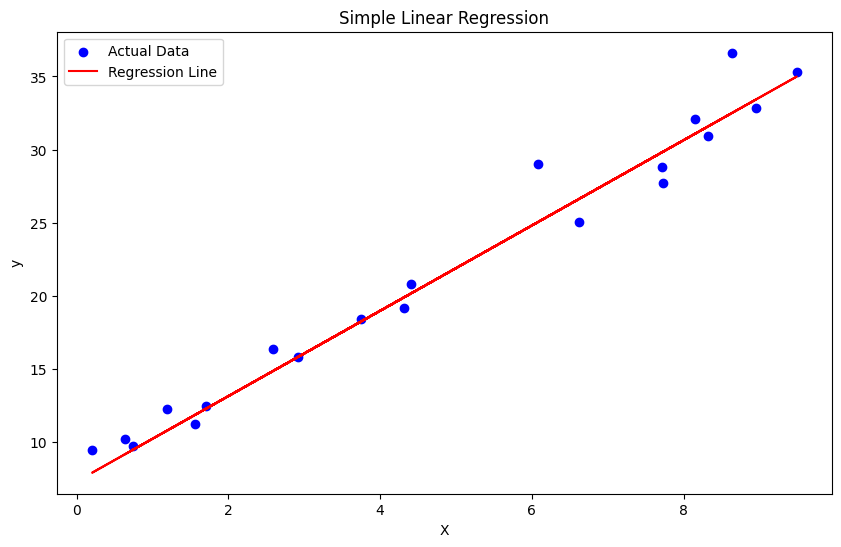

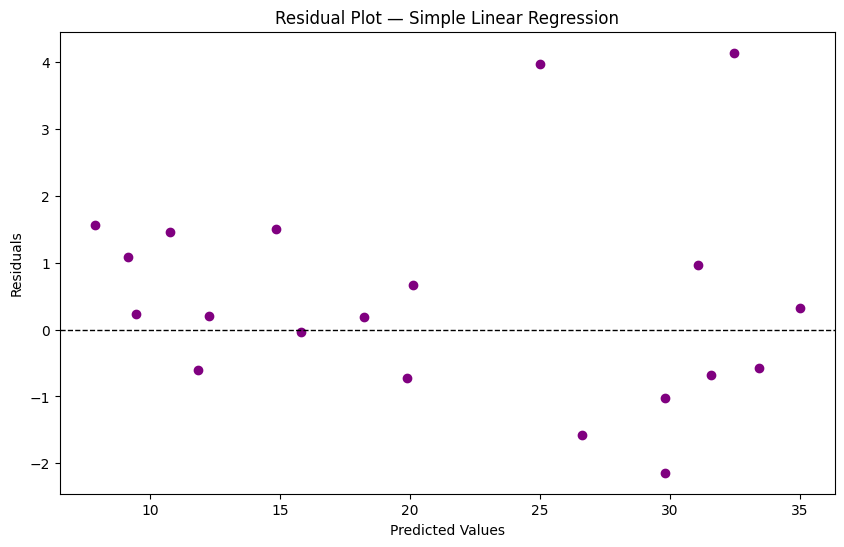

In [2]:
np.random.seed(42)
X_simple = np.random.rand(100, 1) * 10
y_simple = 3 * X_simple + 7 + np.random.randn(100, 1) * 2

X_train, X_test, y_train, y_test = train_test_split(
    X_simple, y_simple, test_size=0.2, random_state=42)

simple_lr = LinearRegression()
simple_lr.fit(X_train, y_train)
y_pred_simple = simple_lr.predict(X_test)

plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='blue', label='Actual Data')
plt.plot(X_test, y_pred_simple, color='red', label='Regression Line')
plt.title('Simple Linear Regression')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

# Residual Plot
residuals_simple = y_test - y_pred_simple
plt.figure(figsize=(10, 6))
plt.scatter(y_pred_simple, residuals_simple, color='purple')
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.title('Residual Plot — Simple Linear Regression')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.show()

###Multiple Linear Regression

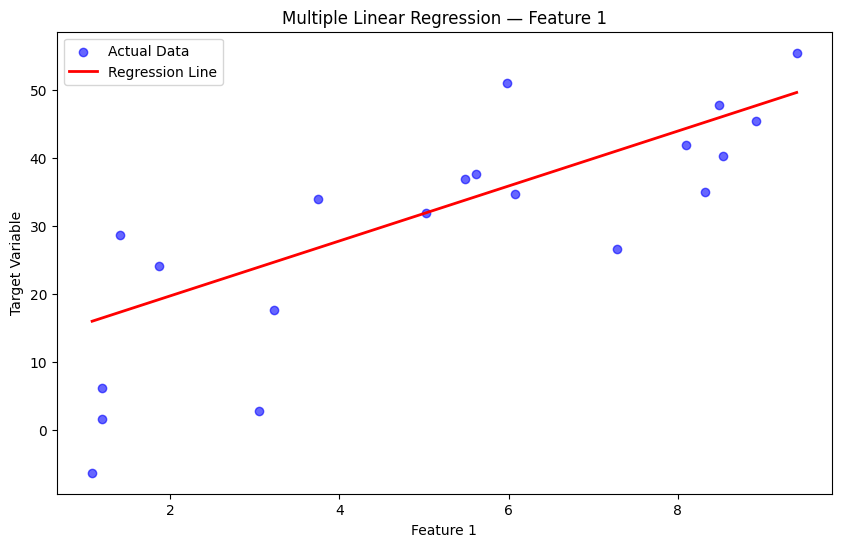

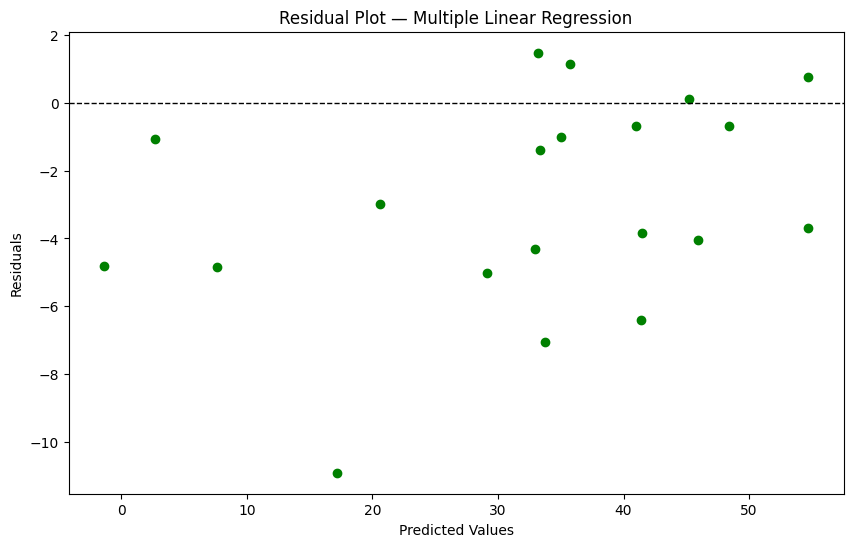

Simple Linear Regression Metrics:
  MSE: 2.61
  R2:  0.97

Multiple Linear Regression Metrics:
  MSE: 18.16
  R2:  0.94


In [3]:
np.random.seed(42)
X_multi = np.random.rand(100, 3) * 10
y_multi = (4 * X_multi[:, 0] + 3 * X_multi[:, 1]
           - 2 * X_multi[:, 2] + 5 + np.random.randn(100) * 3)

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y_multi, test_size=0.2, random_state=42)

multi_lr = LinearRegression()
multi_lr.fit(X_train_m, y_train_m)
y_pred_multi = multi_lr.predict(X_test_m)

# Visualize one feature
feature_index = 0
fixed_features = np.mean(X_test_m, axis=0)
x_values = np.linspace(X_test_m[:, feature_index].min(),
                       X_test_m[:, feature_index].max(), 100).reshape(-1, 1)
X_plot = np.tile(fixed_features, (x_values.shape[0], 1))
X_plot[:, feature_index] = x_values[:, 0]
y_plot = multi_lr.predict(X_plot)

plt.figure(figsize=(10, 6))
plt.scatter(X_test_m[:, feature_index], y_test_m, color='blue', label='Actual Data', alpha=0.6)
plt.plot(x_values, y_plot, color='red', label='Regression Line', linewidth=2)
plt.title(f'Multiple Linear Regression — Feature {feature_index + 1}')
plt.xlabel(f'Feature {feature_index + 1}')
plt.ylabel('Target Variable')
plt.legend()
plt.show()

# Residual Plot — Multiple Regression
residuals_multi = y_test_m - y_pred_multi
plt.figure(figsize=(10, 6))
plt.scatter(y_pred_multi, residuals_multi, color='green')
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.title('Residual Plot — Multiple Linear Regression')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.show()

print("Simple Linear Regression Metrics:")
print(f"  MSE: {mean_squared_error(y_test, y_pred_simple):.2f}")
print(f"  R2:  {r2_score(y_test, y_pred_simple):.2f}")
print("\nMultiple Linear Regression Metrics:")
print(f"  MSE: {mean_squared_error(y_test_m, y_pred_multi):.2f}")
print(f"  R2:  {r2_score(y_test_m, y_pred_multi):.2f}")

### Regression on Student Performance Dataset


In [4]:
# from google.colab import drive
# drive.mount('/content/drive')

# df_raw = pd.read_csv('/content/drive/MyDrive/foundation of data science/Practicals/Student_Performance.csv')
# df_raw.head()